# K-means Clustering

In [5]:

!pip install sentence-transformers scikit-learn pandas numpy matplotlib seaborn plotly umap-learn tqdm deep-translator

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
import umap
import re
from tqdm import tqdm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("All libraries imported!")

All libraries imported!


In [4]:
# Load your CSV
df = pd.read_csv('final_trendingtopics.csv')  # or 'twitter_data_cleaned.csv' if you saved it from EDA

print(f"Dataset: {len(df):,} tweets")
print(f"Columns: {list(df.columns)}")
print(f"\nTopics: {df['topic'].unique()}")
df

Dataset: 10,233 tweets
Columns: ['id', 'text', 'created_at', 'username', 'likes', 'retweets', 'topic', 'timestamp', 'text_cleaned', 'text_translated', 'detected_lang']

Topics: <StringArray>
['Super Bowl LX', 'Winter Olympics 2026 Milano', 'Politics']
Length: 3, dtype: str


,id,text,created_at,username,likes,retweets,topic,timestamp,text_cleaned,text_translated,detected_lang
0,1960875468531621946,@PsyGuy007 bien vue super les gars...,2025-08-28,JaegerStep78492,0.0,NaN,Super Bowl LX,NaN,bien vue super les gars...,good view great guys...,fr
1,1960973143008292871,"You know what, I've ALSO been a splendid nigga...",2025-08-28,JSRingo,209.0,NaN,Super Bowl LX,NaN,"You know what, I've ALSO been a splendid nigga...","You know what, I've ALSO been a splendid nigga...",en
2,1961159089544990909,@fashion_nfl Don’t think enough people are tal...,2025-08-28,p23rce,479.0,NaN,Super Bowl LX,NaN,Don’t think enough people are talking about th...,Don’t think enough people are talking about th...,en
3,1960932935676387741,RT @tahsin_adib: NINGNING telling winter it mu...,2025-08-28,hidden_faayz,0.0,NaN,Winter Olympics 2026 Milano,NaN,NINGNING telling winter it must've take a long...,NINGNING telling winter it must've take a long...,en
4,1961003661548741029,Super sleepy. https://t.co/FMEc5ShIuv,2025-08-28,FajitaFantom,17.0,NaN,Super Bowl LX,NaN,Super sleepy.,Super sleepy.,af
...,...,...,...,...,...,...,...,...,...,...,...
10228,"""2028188410528100663",Fire emblem fates method in 2026 ooowee,2026-03-01,tivstippi,1018.0,NaN,Politics,NaN,Fire emblem fates method in 2026 ooowee,Fire emblem fates method in 2026 ooowee,en
10229,"""2028196713404498110",@DanielBursan ישראל אפרטהייד 2026,2026-03-01,michaelrommy2,4.0,NaN,Politics,NaN,ישראל אפרטהייד 2026,Israel Apartheid 2026,he
10230,"""2027919772092977172",RT @HS_News_: Harry performing “Aperture” at t...,2026-03-01,drpr_1019,0.0,NaN,Politics,NaN,Harry performing “Aperture” at the Brits 2026\...,Harry performing “Aperture” at the Brits 2026\...,en
10231,"""2028109238380151207",Roderic O'Gorman of the Green Party is getting...,2026-03-01,MickOKeeffe,24924.0,NaN,Politics,NaN,Roderic O'Gorman of the Green Party is getting...,Roderic O'Gorman of the Green Party is getting...,en


In [6]:
from langdetect import detect, LangDetectException

def detect_lang(text):
    try:
        if len(str(text).strip()) > 10:
            return detect(str(text))
        return 'unknown'
    except:
        return 'unknown'

df['detected_lang_var'] = df['text_translated'].apply(detect_lang)

lang_counts = df['detected_lang_var'].value_counts()

print(f"Language Distribution of all the tweets):\n")
for lang, count in lang_counts.head(10).items():
    pct = count / len(df) * 100
    print(f"  {lang}: {count} ({pct:.1f}%)")

print(f"\nEnglish tweets: {(df['detected_lang_var'] == 'en').sum()} ({(df['detected_lang_var'] == 'en').sum()/len(df)*100:.1f}%)")

Language Distribution of all the tweets):

  en: 9642 (94.2%)
  de: 89 (0.9%)
  id: 56 (0.5%)
  af: 47 (0.5%)
  unknown: 38 (0.4%)
  bn: 34 (0.3%)
  fr: 32 (0.3%)
  ca: 29 (0.3%)
  it: 29 (0.3%)
  tl: 28 (0.3%)

English tweets: 9642 (94.2%)


In [10]:
df = df[df['detected_lang_var'] == 'en']
df = df.reset_index(drop=True)

In [12]:
df.head(10)

,id,text,created_at,username,likes,retweets,topic,timestamp,text_cleaned,text_translated,detected_lang,detected_lang_var
0,1960973143008292871,"You know what, I've ALSO been a splendid nigga...",2025-08-28,JSRingo,209.0,NaN,Super Bowl LX,NaN,"You know what, I've ALSO been a splendid nigga...","You know what, I've ALSO been a splendid nigga...",en,en
1,1961159089544990909,@fashion_nfl Don’t think enough people are tal...,2025-08-28,p23rce,479.0,NaN,Super Bowl LX,NaN,Don’t think enough people are talking about th...,Don’t think enough people are talking about th...,en,en
2,1960932935676387741,RT @tahsin_adib: NINGNING telling winter it mu...,2025-08-28,hidden_faayz,0.0,NaN,Winter Olympics 2026 Milano,NaN,NINGNING telling winter it must've take a long...,NINGNING telling winter it must've take a long...,en,en
3,1961078342188240986,@FabrizioRomano Check $RIZZ out guysWe're stil...,2025-08-28,Nazariite,3.0,NaN,Super Bowl LX,NaN,Check $RIZZ out guysWe're still super early on...,Check $RIZZ out guysWe're still super early on...,en,en
4,1960861972188033264,Nvidia (NVDA) earnings report Q2 2026 https://...,2025-08-28,KWoljevach71778,54.0,NaN,Winter Olympics 2026 Milano,NaN,Nvidia (NVDA) earnings report Q2 2026,Nvidia (NVDA) earnings report Q2 2026,en,en
5,1961104466297659629,“Republicans against Trump”Supports democrat w...,2025-08-28,mesnickerlicker,28.0,NaN,Super Bowl LX,NaN,“Republicans against Trump”Supports democrat w...,“Republicans against Trump”Supports democrat w...,en,en
6,1961169372170309929,RT @laymagdalene333: not super surprising but ...,2025-08-28,rosyghoul,0.0,NaN,Super Bowl LX,NaN,not super surprising but interesting to see pe...,not super surprising but interesting to see pe...,en,en
7,1961148846849077515,RT @_OgStu: Opening your set with a unrealease...,2025-08-28,THEEGAOAT,0.0,NaN,Super Bowl LX,NaN,Opening your set with a unrealeased song at th...,Opening your set with a unrealeased song at th...,en,en
8,1960931063741481316,RT @ComicsShauna: He didn't really make him le...,2025-08-28,c_sksksksks,0.0,NaN,Super Bowl LX,NaN,He didn't really make him less powerful tbh. H...,He didn't really make him less powerful tbh. H...,en,en
9,1961126748726464666,RT @2_2597: I'm super excited for FAST ZONE 🥹 ...,2025-08-28,anon_sincerely,0.0,NaN,Super Bowl LX,NaN,I'm super excited for FAST ZONE It reminded me...,I'm super excited for FAST ZONE It reminded me...,en,en


## 4. Generate Embeddings (Hugging Face Model)

In [13]:
MODEL_NAME = 'all-MiniLM-L6-v2'

print(f"Loading model: {MODEL_NAME}")
print("First run will download the model...\n")

model = SentenceTransformer(MODEL_NAME)

print(f"Model loaded!")
print(f"Embedding dimensions: {model.get_sentence_embedding_dimension()}")
print(f"Max sequence length: {model.max_seq_length} tokens")

Loading model: all-MiniLM-L6-v2
First run will download the model...



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!
Embedding dimensions: 384
Max sequence length: 256 tokens


In [14]:
# Generate embeddings
print(f"Generating embeddings for {len(df):,} tweets...")
print("This may take a few minutes...\n")

texts = df['text_cleaned'].tolist()

# Encode with progress bar
embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True
)

print(f"\nEmbeddings generated!")
print(f"Shape: {embeddings.shape}")
print(f"   • {embeddings.shape[0]:,} tweets")
print(f"   • {embeddings.shape[1]} dimensions each")

# Save embeddings
np.save('twitter_embeddings.npy', embeddings)
print("\nSaved to 'twitter_embeddings.npy'")

Generating embeddings for 9,642 tweets...
This may take a few minutes...



Batches:   0%|          | 0/302 [00:00<?, ?it/s]


Embeddings generated!
Shape: (9642, 384)
   • 9,642 tweets
   • 384 dimensions each

Saved to 'twitter_embeddings.npy'


In [17]:
# Quick check: similarity between tweets
from sklearn.metrics.pairwise import cosine_similarity

# Compare first two tweets
sim = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
print(f"Sample similarity check:")
print(f"\nTweet 1: {texts[0]}")
print(f"Tweet 2: {texts[1]}")
print(f"\nCosine similarity: {sim:.4f}")
print(f"Interpretation: {sim:.2f} means {'similar' if sim > 0.5 else 'different'} content")

Sample similarity check:

Tweet 1: You know what, I've ALSO been a splendid nigga as of late, I deserve a reward. Think I'm gonna buy myself the new Super Robot Wars game as a treat.
Tweet 2: Don’t think enough people are talking about the Jets, super fire

Cosine similarity: 0.0192
Interpretation: 0.02 means different content


## 5. Find Optimal K (Elbow Method)

In [18]:
# Test different K values
K_range = range(2, 21)  # Test K = 2 to 20

inertias = []
silhouette_scores = []
davies_bouldin_scores = []

print("Testing different K values...")
print("This will take a few minutes...\n")

for k in tqdm(K_range, desc="Testing K"):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(embeddings, labels))
    davies_bouldin_scores.append(davies_bouldin_score(embeddings, labels))

print("\nAnalysis complete!")

Testing different K values...
This will take a few minutes...



Testing K: 100%|██████████| 19/19 [01:00<00:00,  3.16s/it]


Analysis complete!


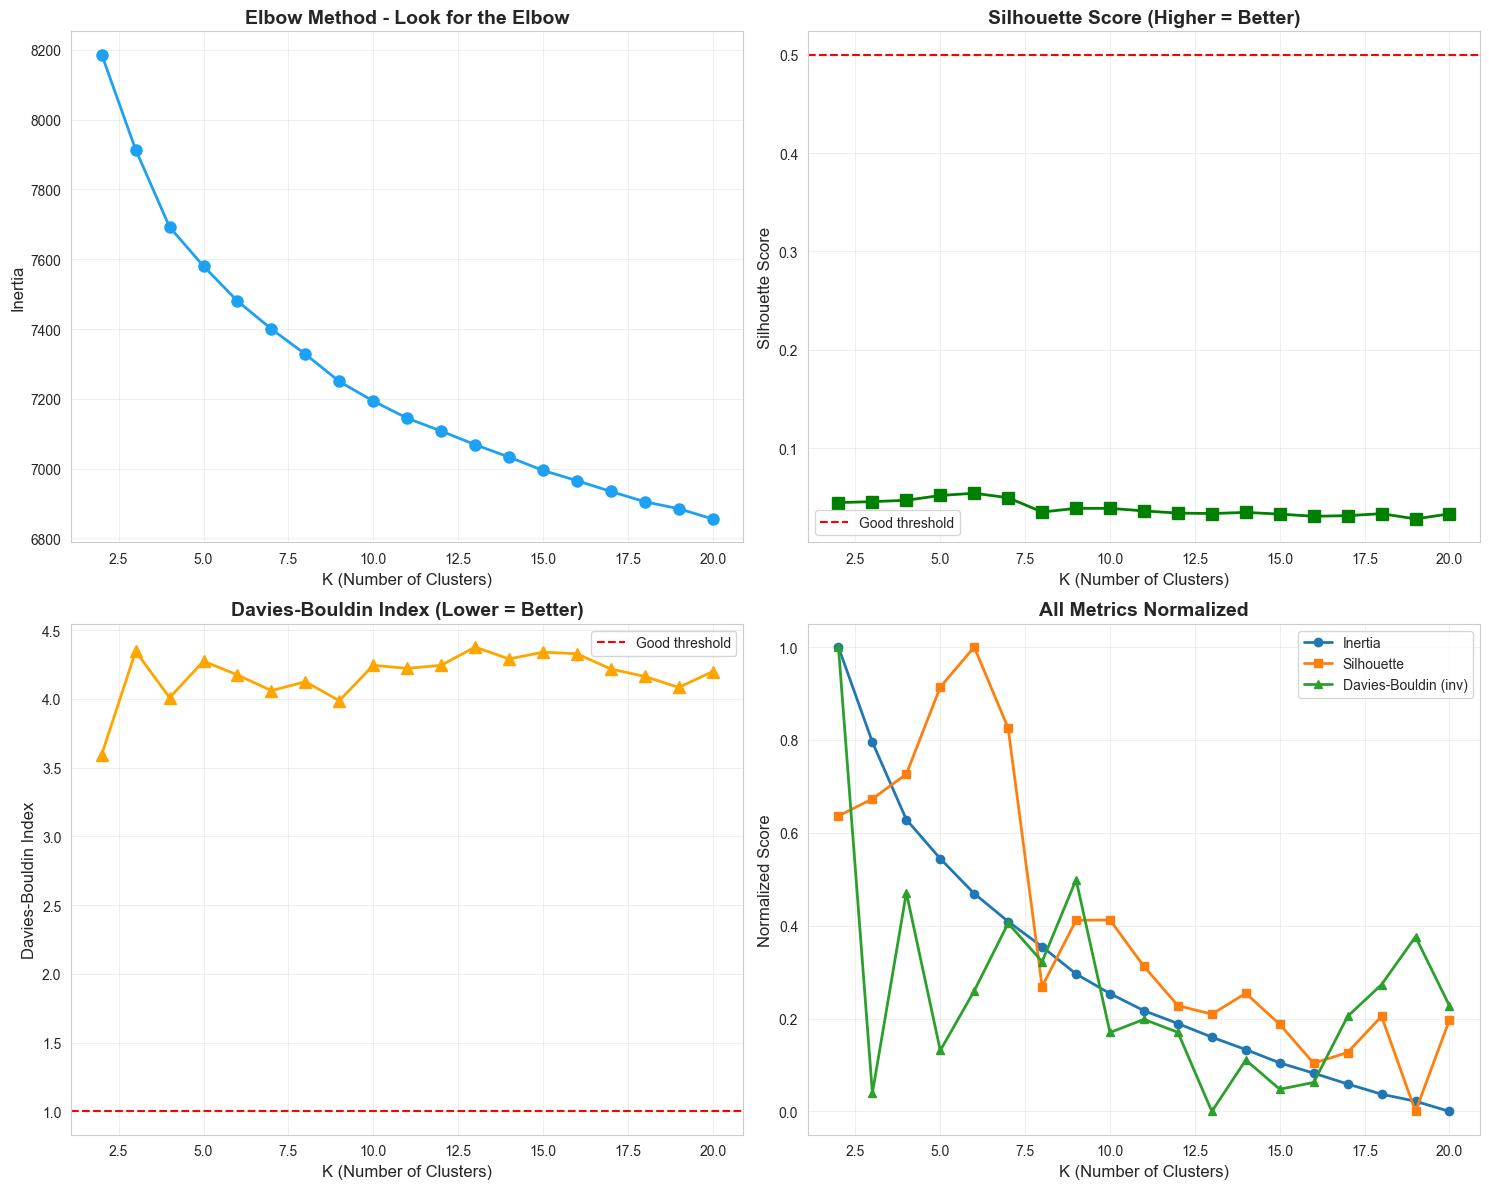

In [19]:
# Visualize metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Elbow curve (inertia)
axes[0, 0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='#1DA1F2')
axes[0, 0].set_xlabel('K (Number of Clusters)', fontsize=12)
axes[0, 0].set_ylabel('Inertia', fontsize=12)
axes[0, 0].set_title('Elbow Method - Look for the Elbow', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Silhouette score (higher is better)
axes[0, 1].plot(K_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='green')
axes[0, 1].set_xlabel('K (Number of Clusters)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title('Silhouette Score (Higher = Better)', fontsize=14, fontweight='bold')
axes[0, 1].axhline(y=0.5, color='red', linestyle='--', label='Good threshold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Davies-Bouldin (lower is better)
axes[1, 0].plot(K_range, davies_bouldin_scores, marker='^', linewidth=2, markersize=8, color='orange')
axes[1, 0].set_xlabel('K (Number of Clusters)', fontsize=12)
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1, 0].set_title('Davies-Bouldin Index (Lower = Better)', fontsize=14, fontweight='bold')
axes[1, 0].axhline(y=1.0, color='red', linestyle='--', label='Good threshold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. All normalized
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
axes[1, 1].plot(K_range, scaler.fit_transform(np.array(inertias).reshape(-1, 1)).flatten(), 
                marker='o', label='Inertia', linewidth=2)
axes[1, 1].plot(K_range, scaler.fit_transform(np.array(silhouette_scores).reshape(-1, 1)).flatten(), 
                marker='s', label='Silhouette', linewidth=2)
axes[1, 1].plot(K_range, 1 - scaler.fit_transform(np.array(davies_bouldin_scores).reshape(-1, 1)).flatten(), 
                marker='^', label='Davies-Bouldin (inv)', linewidth=2)
axes[1, 1].set_xlabel('K (Number of Clusters)', fontsize=12)
axes[1, 1].set_ylabel('Normalized Score', fontsize=12)
axes[1, 1].set_title('All Metrics Normalized', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Metrics table
metrics_df = pd.DataFrame({
    'K': list(K_range),
    'Inertia': inertias,
    'Silhouette': silhouette_scores,
    'Davies-Bouldin': davies_bouldin_scores
})

print("METRICS SUMMARY:\n")
print(metrics_df.to_string(index=False))

best_k_sil = metrics_df.loc[metrics_df['Silhouette'].idxmax(), 'K']
best_k_db = metrics_df.loc[metrics_df['Davies-Bouldin'].idxmin(), 'K']

print(f"\n🏆 Best K by Silhouette: {best_k_sil} (score: {metrics_df.loc[metrics_df['Silhouette'].idxmax(), 'Silhouette']:.4f})")
print(f"🏆 Best K by Davies-Bouldin: {best_k_db} (score: {metrics_df.loc[metrics_df['Davies-Bouldin'].idxmin(), 'Davies-Bouldin']:.4f})")

print(f"\nRecommended K range: {best_k_sil - 2} to {best_k_sil + 2}")
print(f"Look for the 'elbow' in the inertia plot above!")

METRICS SUMMARY:

 K     Inertia  Silhouette  Davies-Bouldin
 2 8186.565918    0.045016        3.595037
 3 7914.108398    0.045973        4.345460
 4 7692.365234    0.047365        4.008243
 5 7580.155273    0.052252        4.273761
 6 7480.268066    0.054498        4.173504
 7 7400.091797    0.049943        4.059632
 8 7328.037598    0.035439        4.124240
 9 7249.907715    0.039157        3.986403
10 7193.686523    0.039173        4.243510
11 7144.693848    0.036567        4.221415
12 7107.796875    0.034369        4.243244
13 7068.863281    0.033885        4.376304
14 7033.234863    0.035057        4.289769
15 6995.095215    0.033318        4.338984
16 6965.599609    0.031131        4.327571
17 6934.671875    0.031734        4.216324
18 6905.355469    0.033768        4.162888
19 6885.183594    0.028426        4.082422
20 6856.011230    0.033560        4.198470

🏆 Best K by Silhouette: 6 (score: 0.0545)
🏆 Best K by Davies-Bouldin: 2 (score: 3.5950)

Recommended K range: 4 to 8
Look

## 6. Train K-Means with Optimal K

In [36]:
# Set optimal K based on analysis above
OPTIMAL_K = 6

print(f"Training K-Means with K = {OPTIMAL_K}...\n")

kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=20,
    max_iter=300
)

cluster_labels = kmeans_final.fit_predict(embeddings)
df['cluster'] = cluster_labels

print("Training complete!\n")
print(f"Final Metrics:")
print(f"   • Inertia: {kmeans_final.inertia_:.2f}")
print(f"   • Silhouette: {silhouette_score(embeddings, cluster_labels):.4f}")
print(f"   • Davies-Bouldin: {davies_bouldin_score(embeddings, cluster_labels):.4f}")
print(f"   • Calinski-Harabasz: {calinski_harabasz_score(embeddings, cluster_labels):.2f}")

Training K-Means with K = 6...

Training complete!

Final Metrics:
   • Inertia: 7480.27
   • Silhouette: 0.0545
   • Davies-Bouldin: 4.1735
   • Calinski-Harabasz: 289.96


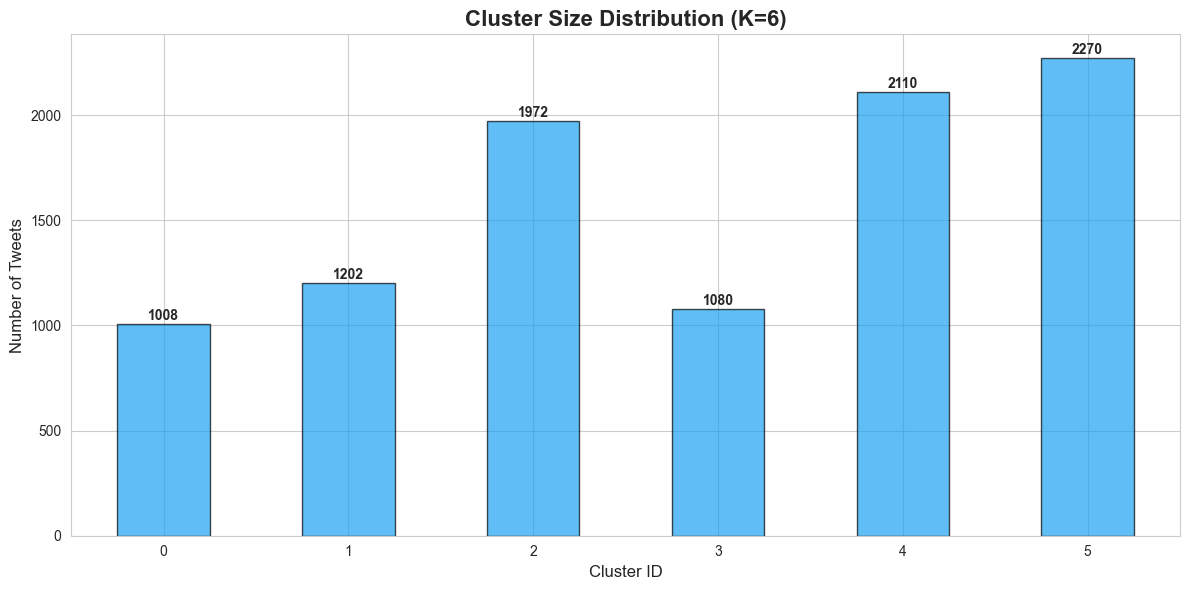


Cluster Statistics:
   • Largest: 2270 tweets (Cluster 5)
   • Smallest: 1008 tweets (Cluster 0)
   • Average: 1607.0 tweets
   • Median: 1587.0 tweets


In [37]:
# Cluster size distribution
cluster_counts = df['cluster'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
cluster_counts.plot(kind='bar', color='#1DA1F2', edgecolor='black', alpha=0.7)
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.title(f'Cluster Size Distribution (K={OPTIMAL_K})', fontsize=16, fontweight='bold')
plt.xticks(rotation=0)

for i, v in enumerate(cluster_counts):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nCluster Statistics:")
print(f"   • Largest: {cluster_counts.max()} tweets (Cluster {cluster_counts.idxmax()})")
print(f"   • Smallest: {cluster_counts.min()} tweets (Cluster {cluster_counts.idxmin()})")
print(f"   • Average: {cluster_counts.mean():.1f} tweets")
print(f"   • Median: {cluster_counts.median():.1f} tweets")

## 7. Analyze Clusters by Original Topic

📊 CLUSTER vs TOPIC Distribution:

topic    Politics  Super Bowl LX  Winter Olympics 2026 Milano
cluster                                                      
0               0             19                          989
1              31            456                          715
2               0           1865                          107
3             315            456                          309
4              90             44                         1976
5              13           1780                          477



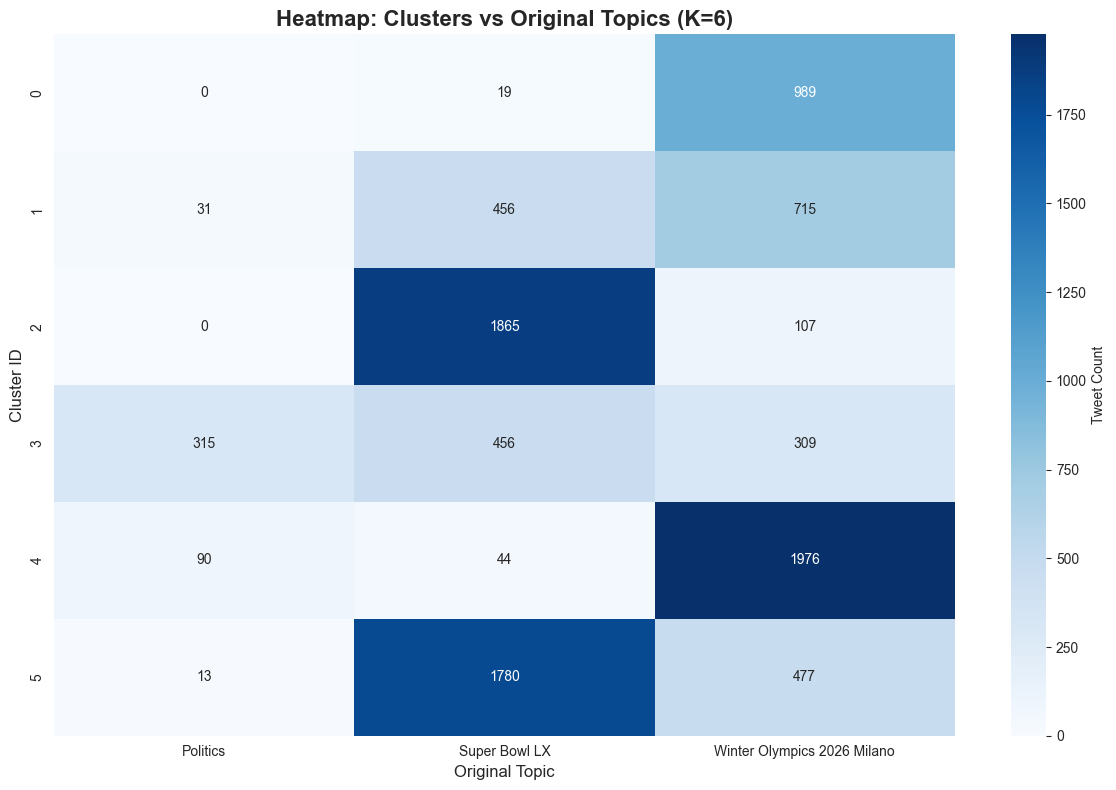


💡 This shows how well clusters align with original topics
💡 Diagonal dominance = good clustering


In [38]:
# Cross-tabulation: Clusters vs Original Topics
cluster_topic_matrix = pd.crosstab(df['cluster'], df['topic'])

print("📊 CLUSTER vs TOPIC Distribution:\n")
print(cluster_topic_matrix)
print("\n" + "="*80)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_topic_matrix, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Tweet Count'})
plt.title(f'Heatmap: Clusters vs Original Topics (K={OPTIMAL_K})', fontsize=16, fontweight='bold')
plt.xlabel('Original Topic', fontsize=12)
plt.ylabel('Cluster ID', fontsize=12)
plt.tight_layout()
plt.show()

print("\n💡 This shows how well clusters align with original topics")
print("💡 Diagonal dominance = good clustering")

## 8. Sample Tweets from Each Cluster

In [39]:
# Show sample tweets from each cluster
print("="*80)
print("SAMPLE TWEETS FROM EACH CLUSTER")
print("="*80)

for cluster_id in range(OPTIMAL_K):
    cluster_tweets = df[df['cluster'] == cluster_id]
    
    print(f"\n{'='*80}")
    print(f"🔹 CLUSTER {cluster_id} ({len(cluster_tweets)} tweets)")
    print(f"{'='*80}")
    
    # Show topic distribution in this cluster
    topic_dist = cluster_tweets['topic'].value_counts()
    print(f"\nTopic distribution:")
    for topic, count in topic_dist.items():
        print(f"  • {topic}: {count} ({count/len(cluster_tweets)*100:.1f}%)")
    
    # Show 5 random samples
    samples = cluster_tweets.sample(min(5, len(cluster_tweets)), random_state=42)
    
    print(f"\nSample tweets:")
    for i, (idx, row) in enumerate(samples.iterrows(), 1):
        print(f"{i}. [{row['topic']}] ❤️ {row['likes']:,}")
        print(f"   {row['text_cleaned'][:150]}...")
        print()

print("="*80)
print("\nan you identify themes in each cluster?")
print("In Week 7, LLMs will auto-generate cluster names!")

SAMPLE TWEETS FROM EACH CLUSTER

🔹 CLUSTER 0 (1008 tweets)

Topic distribution:
  • Winter Olympics 2026 Milano: 989 (98.1%)
  • Super Bowl LX: 19 (1.9%)

Sample tweets:
1. [Winter Olympics 2026 Milano] ❤️ 953.0
   I’m really not ready for another winter storm…...

2. [Winter Olympics 2026 Milano] ❤️ 126.0
   Plain dashcam — v14.2.2.4 on Hwy 17, Northern Ontario. Had to disengage — FSD not yielding for tractor trailer in slush, faded lines, frost heaves, -2...

3. [Winter Olympics 2026 Milano] ❤️ 2,842.0
   Olympics have become irrelevant. We need something new to rally around. Football ain’t it anymore....

4. [Winter Olympics 2026 Milano] ❤️ 53.0
   לפי החיפושים שלי, נכון להיום (6 בינואר 2026), עדיין לא פורסם תאריך רשמי לפריימריס במפלגת העבודה-מרץ. הבחירות לכנסת מתוכננות ל-27 באוקטובר 2026, אז מומ...

5. [Winter Olympics 2026 Milano] ❤️ 0.0
   Amazing News!!!My Charlie Kirk painting will be featured at The Annual Winter Gala which is a black tie event that they…...


🔹 CLUSTER 1 (120

## 9. Simple Keyword Extraction per Cluster

In [40]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def extract_keywords(texts, top_n=10):
    all_words = []
    for text in texts:
        words = text.lower().split()
        # Filter stopwords, URLs, mentions
        words = [w for w in words if w not in ENGLISH_STOP_WORDS 
                 and len(w) > 3 
                 and not w.startswith(('http', '@', '#'))]
        all_words.extend(words)
    
    word_freq = Counter(all_words)
    return word_freq.most_common(top_n)

print("📊 TOP KEYWORDS PER CLUSTER\n")
print("="*80)

for cluster_id in range(OPTIMAL_K):
    tweets = df[df['cluster'] == cluster_id]['text_cleaned'].tolist()
    keywords = extract_keywords(tweets, top_n=10)
    
    print(f"\nCluster {cluster_id} ({len(tweets)} tweets):")
    kw_list = [f"{word}({count})" for word, count in keywords]
    print(f"   {', '.join(kw_list)}")

print("\n" + "="*80)
print("\nThese are simple frequency-based keywords")

📊 TOP KEYWORDS PER CLUSTER


Cluster 0 (1008 tweets):
   winter(591), olympics(176), ������(80), like(61), just(55), olympics.(48), winter.(46), 2026(46), time(38), gold(38)

Cluster 1 (1202 tweets):
   super(412), 2026(376), para(97), ������(87), bowl(63), 2026.(58), pour(50), milano(48), mais(40), ������������(39)

Cluster 2 (1972 tweets):
   super(1815), bowl(1565), halftime(478), bunny(226), bowl.(167), just(154), like(152), people(106), time(104), watch(101)

Cluster 3 (1080 tweets):
   super(404), election(181), 2026(127), trump(92), just(76), people(71), like(61), ������(46), bangladesh(44), going(42)

Cluster 4 (2110 tweets):
   2026(1312), 2026.(239), ������(204), year(117), 2026,(108), january(82), february(78), world(76), 2026?(64), ������������(62)

Cluster 5 (2270 tweets):
   super(1616), 2026(236), ������(210), just(152), like(146), &amp;(105), bowl(101), it’s(66), power(66), excited(62)


These are simple frequency-based keywords


## 10. Save All Results

In [ ]:
# Save everything
df.to_csv('twitter_with_clusters.csv', index=False)
print("Saved: twitter_with_clusters.csv")

np.save('twitter_embeddings.npy', embeddings)
print("Saved: twitter_embeddings.npy")

np.save('cluster_labels.npy', cluster_labels)
print("Saved: cluster_labels.npy")

np.save('embeddings_pca.npy', embeddings_pca)
np.save('embeddings_umap.npy', embeddings_umap)
print("Saved: PCA and UMAP coordinates")

print("\nAll results saved!")